NAME : SAMIM ALI STD ID =202404435 LAB2 PROG2
Problem: Simple Linear Regression using Gradient Descent using Stochastic and Mini-batch Gradient Descent

Daataset: Create single feature single target dataset using sklearn.datasets.make_regresion

Task: (a) Apply Stochastic Gradient Descent on the dataset and find the coefficients theta0 and theta1
Task: (b) Apply Mini-batch Gradient Descent on the dataset and find the coefficients theta0 and theta1


1) Use matplotlib to perform data analysis on the dataset and plot scatter of data, plot distribution of feature and target
2) Normalize the dataset
3) Apply the appropriate gradient descent method
4) Calculate the coefficients
6) Plot the linear regression line
7) Analyze the model on various values of eta
8) Analyze the model on different size of data
9) Compare both coefficients and MSE obtained using both methods

In [113]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [114]:
from sklearn.datasets import make_regression

In [115]:
X, y = make_regression(n_samples=100, n_features=1, n_targets=1, noise = 20, random_state=40)

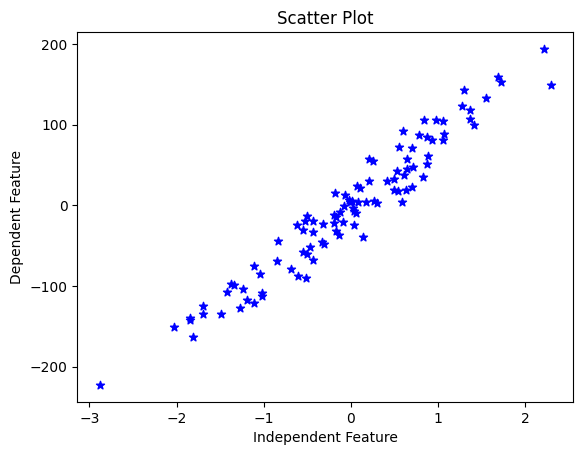

In [116]:
plt.scatter(X, y, color = "blue", marker = "*")
plt.xlabel("Independent Feature")
plt.ylabel("Dependent Feature")
plt.title("Scatter Plot")
plt.show()

In [117]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)
y = scaler.fit_transform(y.reshape(-1, 1))

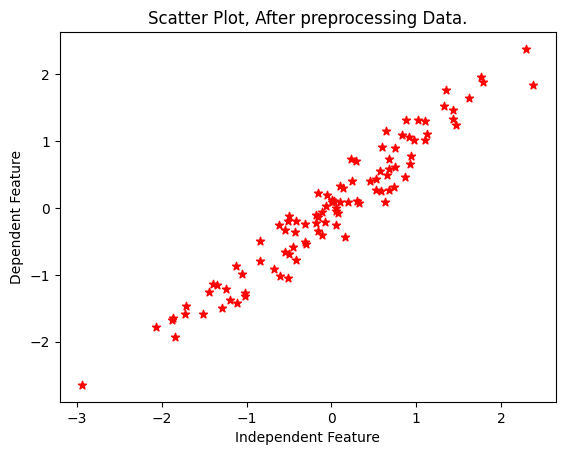

In [118]:
plt.scatter(X, y, color = "red", marker = "*")
plt.xlabel("Independent Feature")
plt.ylabel("Dependent Feature")
plt.title("Scatter Plot, After preprocessing Data.")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

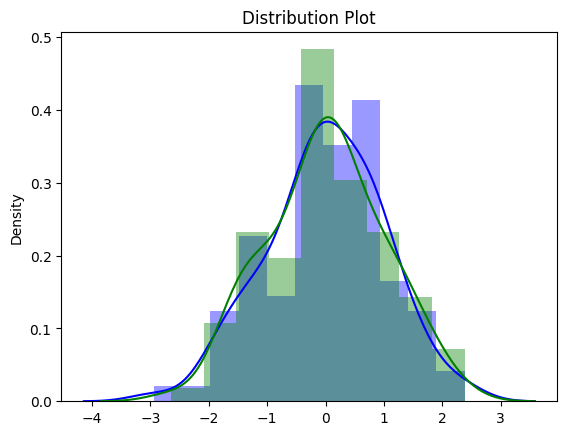

In [119]:
sns.distplot(X, color = "blue")
sns.distplot(y, color = "green")
plt.title("Distribution Plot")
plt.show

In [120]:
# let assume Initial random value of theta0, theta1
theta0 = 0
theta1 = 0

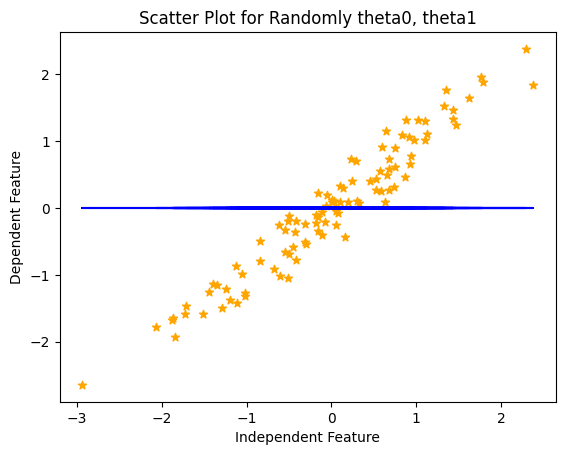

In [121]:
plt.scatter(X, y, color = "orange", marker = "*")
plt.plot(X, theta0 + theta1*X, c = 'b')
plt.xlabel("Independent Feature")
plt.ylabel("Dependent Feature")
plt.title("Scatter Plot for Randomly theta0, theta1")
plt.show()

In [122]:
error = []
t0 = []
t1 = []
eta = 0.01                                # learning rate
n = len(X)                                
for i in range(n):                        
    y_pred = theta0 + theta1*X[i]         
    residual = y_pred - y[i]              
    dL0 = 2*residual                      
    dL1 = 2*residual*X[i]                 
    theta0 = theta0 - eta*dL0             
    theta1 = theta1 - eta*dL1             
    error.append(residual)                
    t0.append(theta0)
    t1.append(theta1)

In [123]:
print(f"updated value of theta 0 : {theta0}")
print(f"updated value of theta 1 : {theta1}")

updated value of theta 0 : [0.0065482]
updated value of theta 1 : [0.84963976]


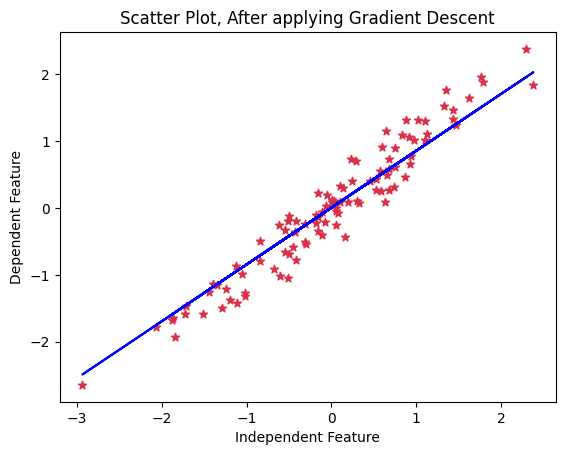

In [124]:
plt.scatter(X, y, color = "#DA3048", marker = "*")
plt.plot(X, theta0 + theta1*X, c = 'b')
plt.xlabel("Independent Feature")
plt.ylabel("Dependent Feature")
plt.title("Scatter Plot, After applying Gradient Descent")
plt.show()

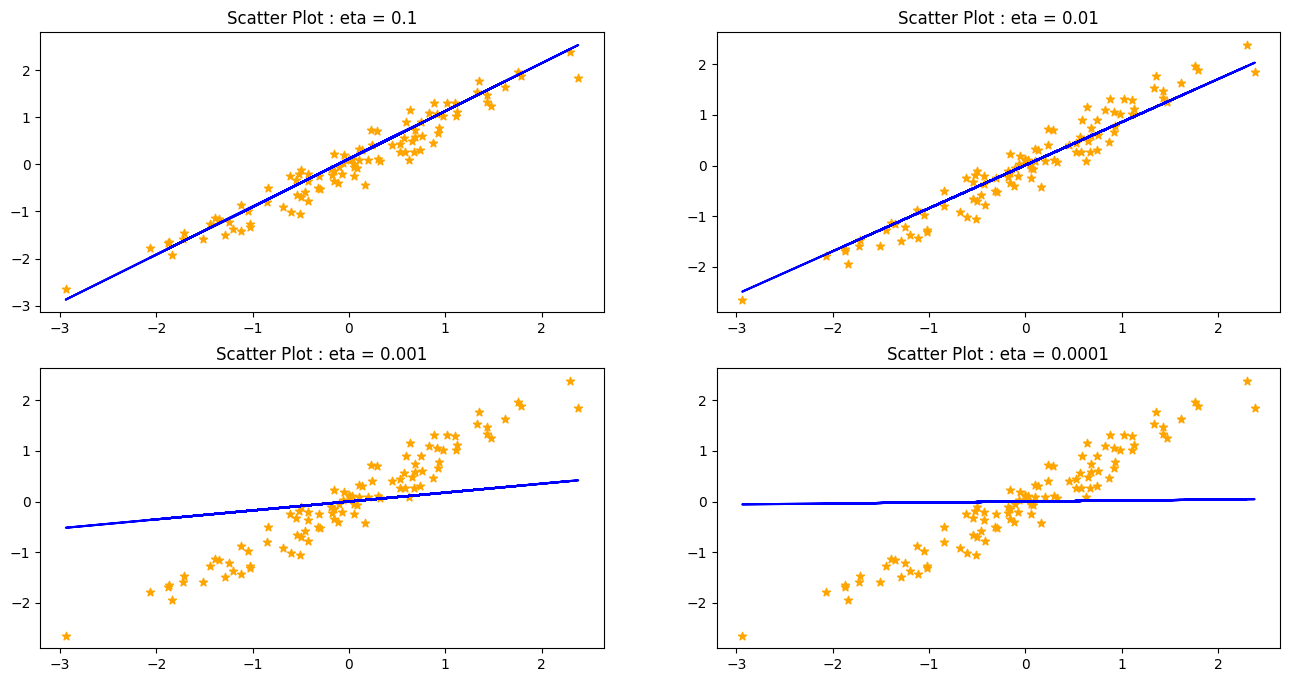

In [125]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
eta = [0.1, 0.01, 0.001, 0.0001]
n = len(X)                                # total no. of data points
for j, ax in enumerate(axes.flat): 
    theta0 = 0
    theta1 = 0
    for i in range(n):                      
        y_pred = theta0 + theta1*X[i]         
        residual = y[i]- y_pred             
        dL0 = -2*residual                      
        dL1 = -2*residual*X[i]                 
        theta0 = theta0 - eta[j]*dL0             
        theta1 = theta1 - eta[j]*dL1             
    ax.scatter(X, y, color = "orange", marker = "*")
    ax.plot(X, theta0 + theta1*X, color = 'b')
    ax.set_title(f"Scatter Plot : eta = {eta[j]}")

In [126]:
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler

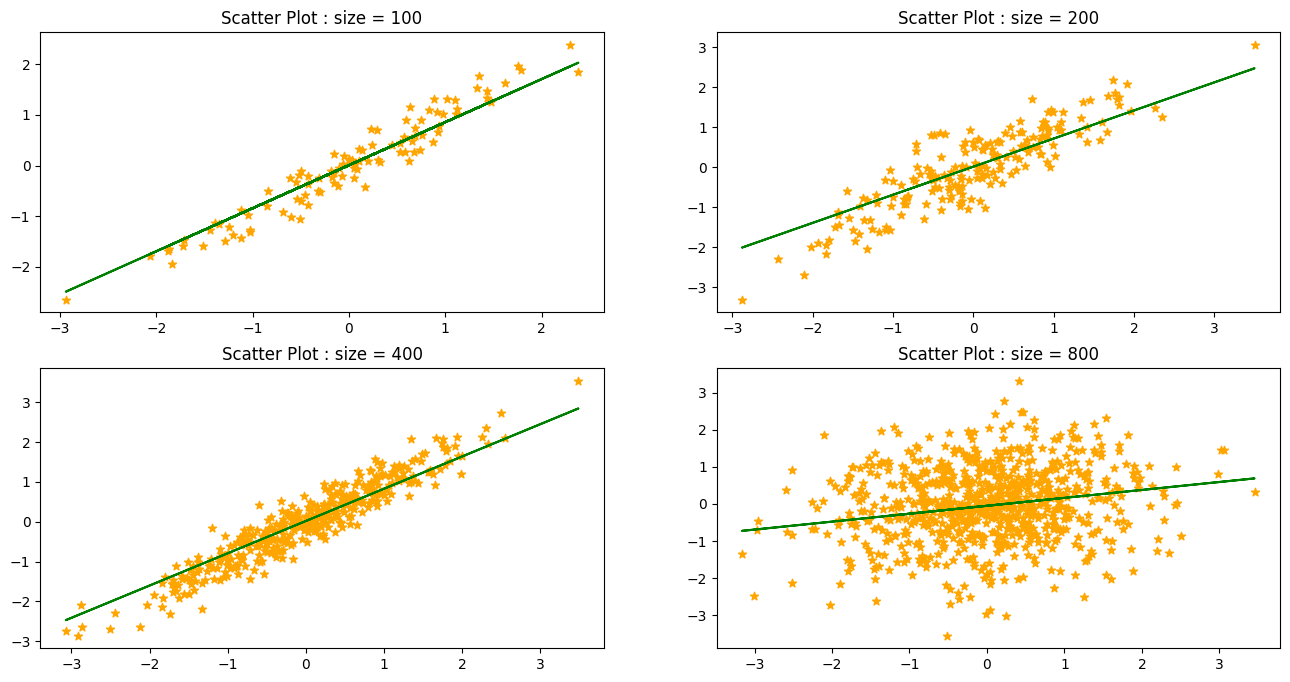

In [127]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
size = [100, 200, 400, 800]
n = len(X)                               # total no. of data points
eta = 0.01

for j, ax in enumerate(axes.flat):
    X, y = make_regression(n_samples=size[j], n_features=1, n_targets=1, noise=20, random_state=40)
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    y = scaler.fit_transform(y.reshape(-1, 1))
    
    theta0 = 0
    theta1 = 0
    for i in range(n):                        # iterating len(X) times
        y_pred = theta0 + theta1*X[i]         # Calculate predicted value
        residual = y[i]- y_pred             
        dL0 = -2*residual                      
        dL1 = -2*residual*X[i]                   # Calculate the loss w.r.t theta1
        theta0 = theta0 - eta*dL0             # update the theta0 value to minimize the loss
        theta1 = theta1 - eta*dL1             # update the theta1 value to minimize the loss
    ax.scatter(X, y, color = "orange", marker = "*")
    ax.plot(X, theta0 + theta1*X, color = 'g')
    ax.set_title(f"Scatter Plot : size = {size[j]}")

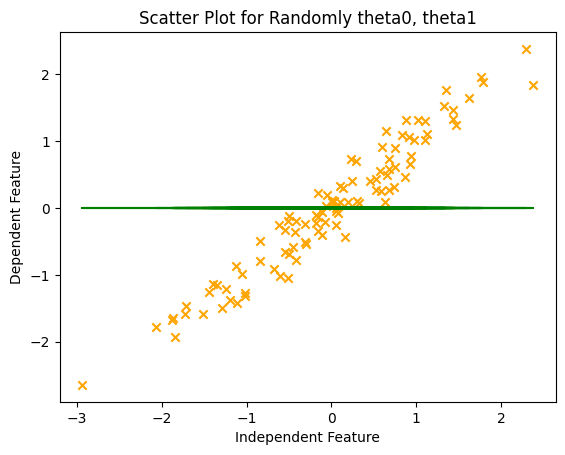

In [128]:


from sklearn.datasets import make_regression
X, y = make_regression(n_samples=100, n_features=1, n_targets=1, noise = 20, random_state=40)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)
y = scaler.fit_transform(y.reshape(-1, 1))

# let assume Initial random value of theta0, theta1
theta0 = 0
theta1 = 0

plt.scatter(X, y, color = "orange", marker = "x")
plt.plot(X, theta0 + theta1*X, c = 'g')
plt.xlabel("Independent Feature")
plt.ylabel("Dependent Feature")
plt.title("Scatter Plot for Randomly theta0, theta1")
plt.show()

In [129]:
error = []
t0 = []
t1 = []
eta = 0.01                                # learning rate
n = len(X)                                # total no. of data points
Batch_size = 10                           # Batch Size

for k in range(100):                                                               # Iterating 100 times
    for i in range(Batch_size):
        y_pred = theta0 + theta1*X[i*Batch_size : (i+1)*Batch_size]                
        residual = y_pred - y[i*Batch_size : (i+1)*Batch_size]                     
        dL0 = (2/Batch_size)*np.sum(residual)                                      
        dL1 = (2/Batch_size)*np.sum(residual*X[i*Batch_size : (i+1)*Batch_size])   
        theta0 = theta0 - eta*dL0                                                  
        theta1 = theta1 - eta*dL1                                                  
    MAE = np.sum(residual)/Batch_size
    error.append(MAE)                                                     
    t0.append(theta0)
    t1.append(theta1)

In [130]:
print(f"updated value of theta 0 : {theta0}")
print(f"updated value of theta 1 : {theta1}")

updated value of theta 0 : -0.00026056340904323386
updated value of theta 1 : 0.9681994793092603


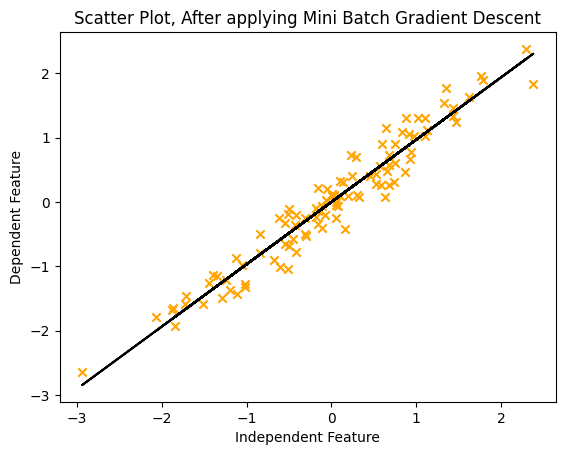

In [131]:
plt.scatter(X, y, color = "orange", marker = "x")
plt.plot(X, theta0 + theta1*X, c = 'black')
plt.xlabel("Independent Feature")
plt.ylabel("Dependent Feature")
plt.title("Scatter Plot, After applying Mini Batch Gradient Descent")
plt.show()

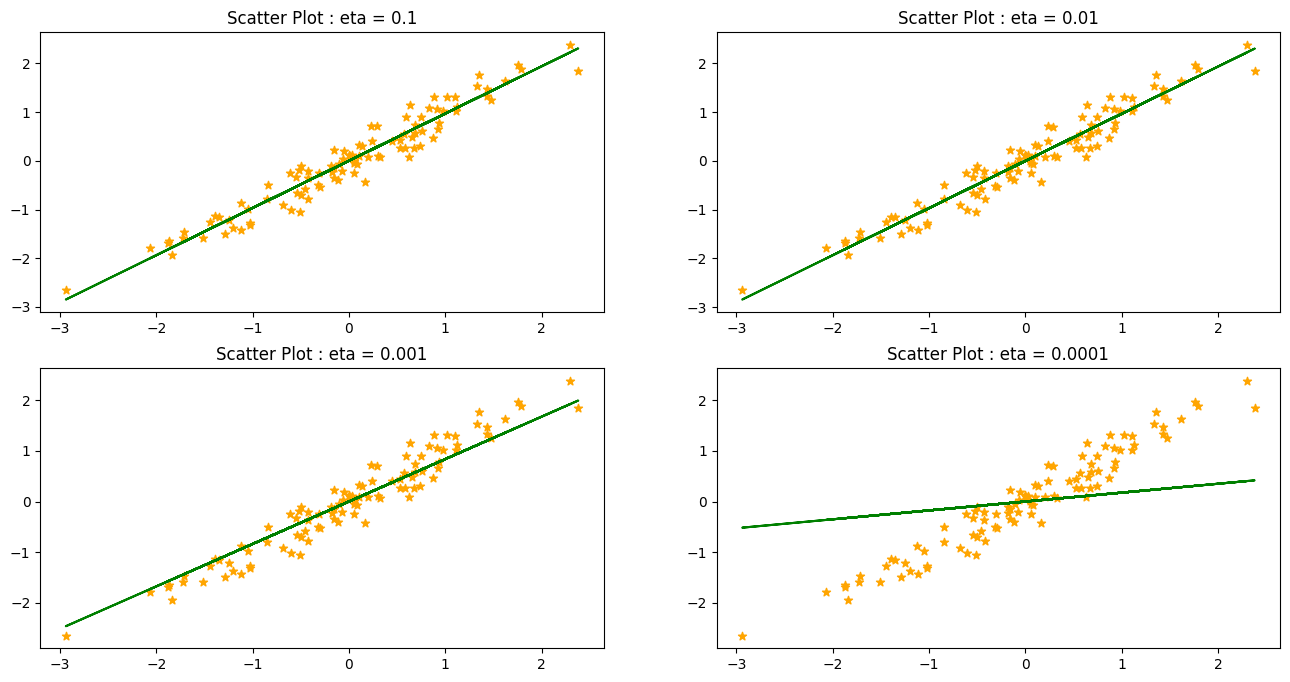

In [132]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
eta = [0.1, 0.01, 0.001, 0.0001]
n = len(X)                                # total no. of data points
for j, ax in enumerate(axes.flat): 
    theta0 = 0
    theta1 = 0
    for k in range(100):                                                               # Iterating 100 times
        for i in range(Batch_size):
            y_pred = theta0 + theta1*X[i*Batch_size : (i+1)*Batch_size]                # Calculate predicted value
            residual = y_pred - y[i*Batch_size : (i+1)*Batch_size]                     # Calculate the error
            dL0 = (2/Batch_size)*np.sum(residual)                                      # calculate the loss w.r.t theta0
            dL1 = (2/Batch_size)*np.sum(residual*X[i*Batch_size : (i+1)*Batch_size])   # Calculate the loss w.r.t theta1
            theta0 = theta0 - eta[j]*dL0                                                  # update the theta0 value to minimize the loss
            theta1 = theta1 - eta[j]*dL1                                                  # update the theta1 value to minimize the loss
    ax.scatter(X, y, color = "orange", marker = "*")
    ax.plot(X, theta0 + theta1*X, color = 'g')
    ax.set_title(f"Scatter Plot : eta = {eta[j]}")


In [133]:
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler

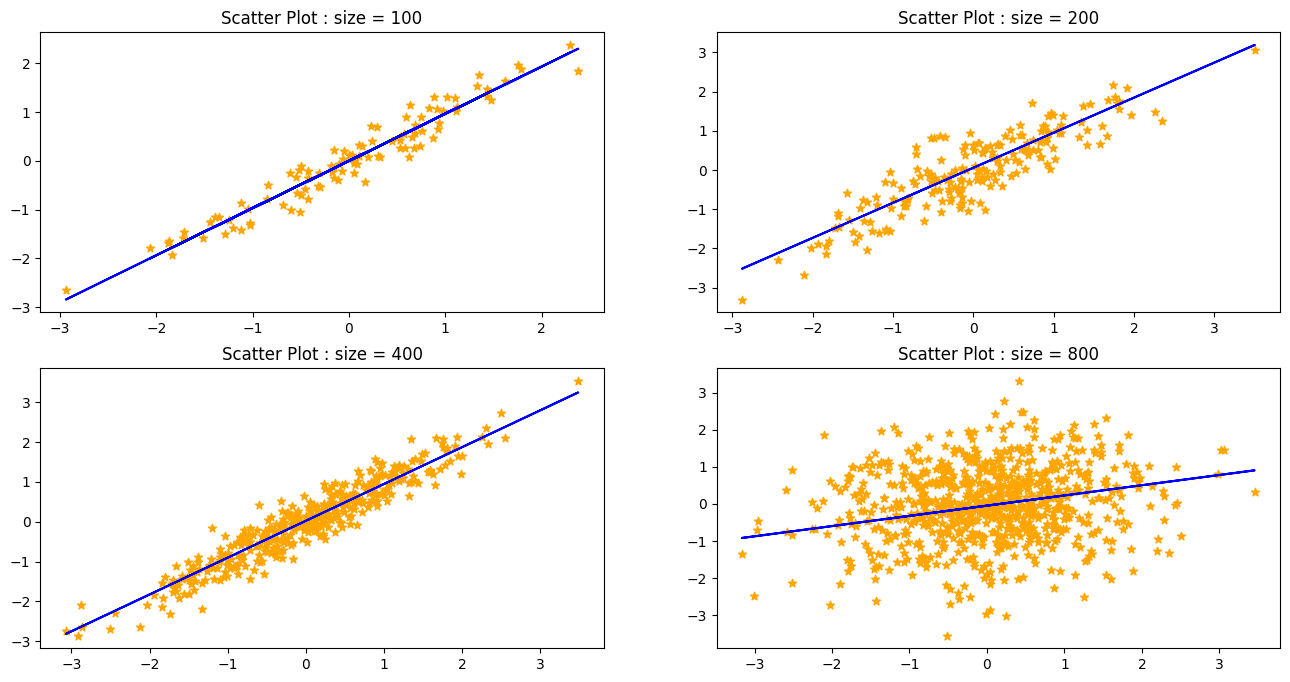

In [134]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
size = [100, 200, 400, 800]
n = len(X)                               # total no. of data points
eta = 0.01

for j, ax in enumerate(axes.flat):
    X, y = make_regression(n_samples=size[j], n_features=1, n_targets=1, noise=20, random_state=40)
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    y = scaler.fit_transform(y.reshape(-1, 1))
    
    theta0 = 0
    theta1 = 0
    for k in range(100):                                                               
        for i in range(Batch_size):
            y_pred = theta0 + theta1*X[i*Batch_size : (i+1)*Batch_size]                
            residual = y_pred - y[i*Batch_size : (i+1)*Batch_size]                     
            dL0 = (2/Batch_size)*np.sum(residual)                                      
            dL1 = (2/Batch_size)*np.sum(residual*X[i*Batch_size : (i+1)*Batch_size])   
            theta0 = theta0 - eta*dL0                                                  
            theta1 = theta1 - eta*dL1                                                  
    ax.scatter(X, y, color = "orange", marker = "*")
    ax.plot(X, theta0 + theta1*X, color = 'b')
    ax.set_title(f"Scatter Plot : size = {size[j]}")

In [135]:
# 9) Compare both coefficients and MSE obtained using both methods
SE = []
for i in range(100):
    SE.append(np.square(error[i]))
MSE = (1/100)*np.sqrt(np.sum(SE))
print(MSE)

0.012142433998715868


In [136]:
len(t0), len(t1), len(error)

(100, 100, 100)

In [137]:
arr = np.array(range(1, 101))
len(arr)

100

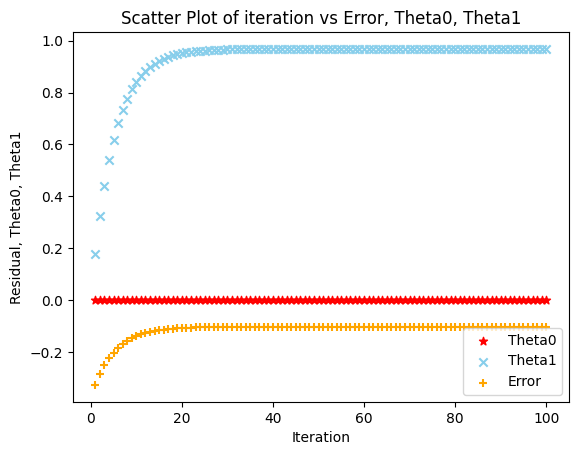

In [138]:
plt.scatter(arr, t0, color = "red", marker = "*", label = "Theta0")
plt.scatter(arr, t1, color = "skyblue", marker = "x", label = "Theta1")
plt.scatter(arr, error, color = "orange", marker = "+", label = "Error")
plt.xlabel("Iteration")
plt.ylabel("Residual, Theta0, Theta1")
plt.legend()
plt.title("Scatter Plot of iteration vs Error, Theta0, Theta1")
plt.show()